<Axes: xlabel='PT08.S1(CO)', ylabel='Time'>

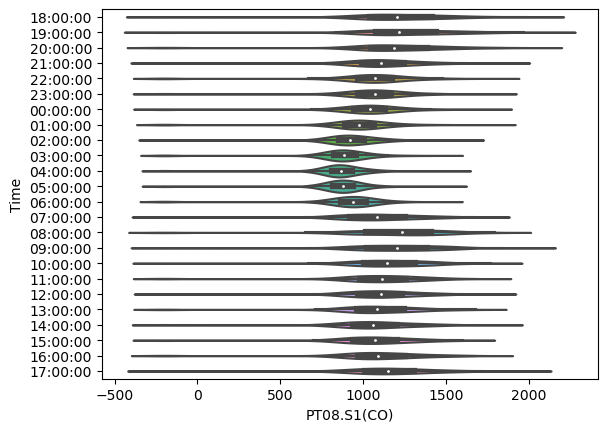

<Axes: xlabel='PT08.S1(CO)', ylabel='Count'>

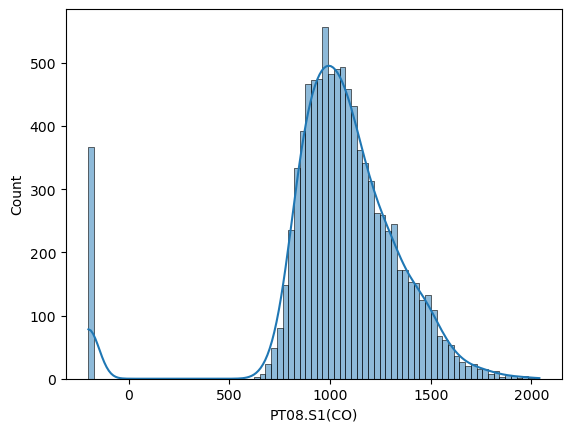

<Figure size 640x480 with 0 Axes>

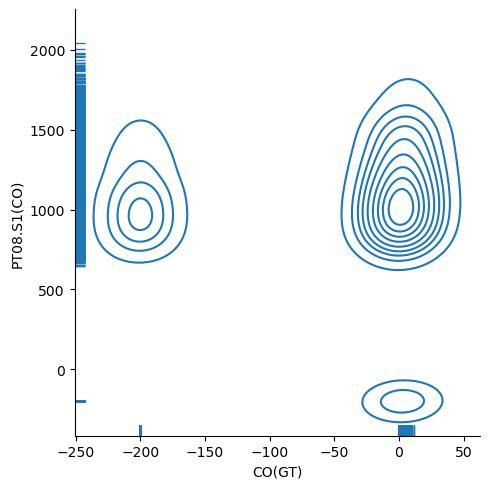

<Axes: xlabel='RH', ylabel='PT08.S1(CO)'>

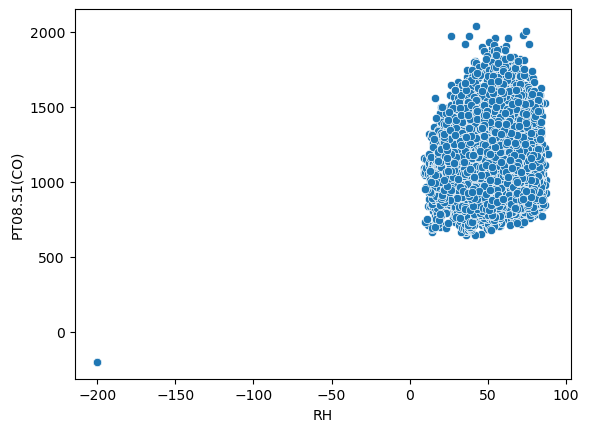

<Axes: xlabel='PT08.S1(CO)', ylabel='AH'>

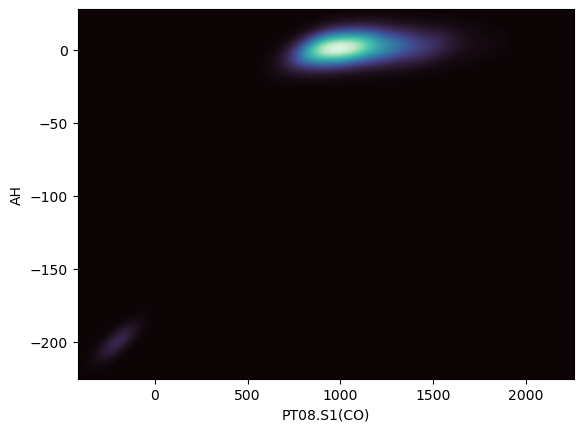

<Axes: xlabel='T', ylabel='PT08.S1(CO)'>

<Axes: xlabel='T', ylabel='PT08.S1(CO)'>

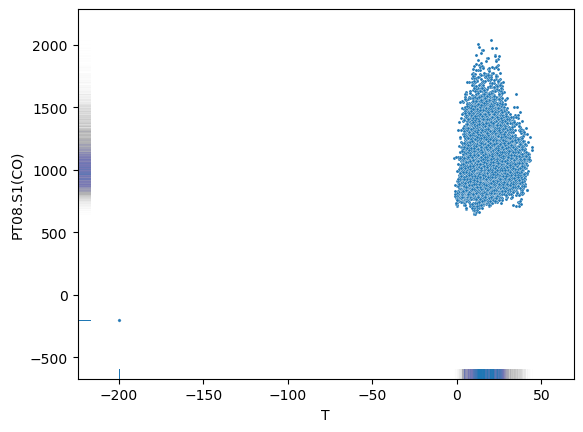

<Figure size 640x480 with 0 Axes>

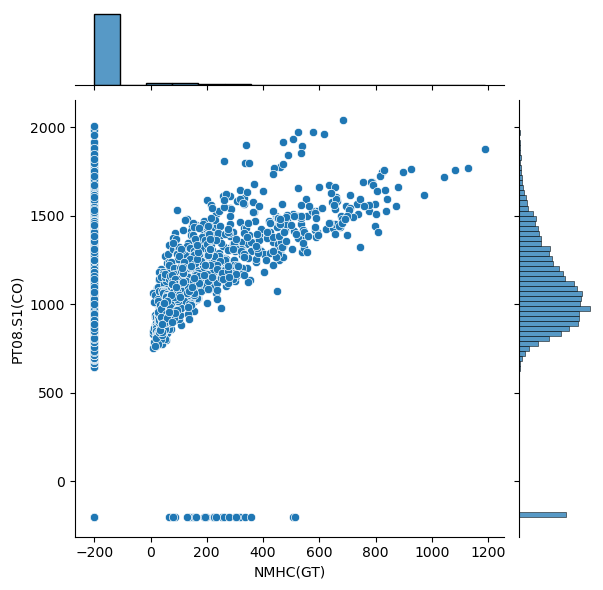

'\ndata=data.astype({\'Date\':\'string\'})\nfor i in range(len(data[\'Date\'])):\n    txt_list=list(data[\'Date\'])[i].split("-")\n    #print(txt_list[1] +\' \'+ txt_list[2] +\'\n\' )\n    month=int(txt_list[1])\n    day=int(txt_list[2])\n    if month in [2,3,4,5,6,7]:\n        idx=31*(month-1)+day\n    elif month==1:\n        idx=day\n    else:\n        idx=6*31+(month-7)+day\n    data.at[i,\'Date\']=str(idx)\n'

PT08.S1(CO)      1.000000
PT08.S5(O3)      0.868372
PT08.S2(NMHC)    0.841610
C6H6(GT)         0.836596
CO(GT)           0.822531
NOx(GT)          0.685891
PT08.S4(NO2)     0.570912
NO2(GT)          0.564228
Time             0.268920
AH               0.198199
RH               0.136018
T                0.092226
Date             0.031437
PT08.S3(NOx)    -0.860097
NMHC(GT)              NaN
Name: PT08.S1(CO), dtype: float64

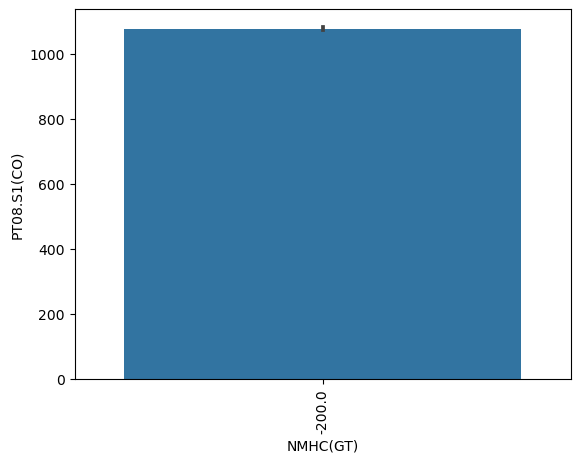

Ridge(alpha=0.001)

3370.491444946167


Lasso(alpha=1e-05)

3370.490009809618


ElasticNet(alpha=0.001, l1_ratio=0.3)

3370.490009809618
best ridge regression result - mse: 4436.72, R2: 0.85
best lasso regression result - mse: 4436.72, R2: 0.85
best elastic regression result - mse: 4433.16, R2: 0.85


In [80]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import zipfile
import pandas as pd

archive=zipfile.ZipFile('AirQualityUCI.zip', 'r')
xlfile=archive.open('AirQualityUCI.xlsx')
data=pd.read_excel(xlfile)
#data.head()
#data.tail()

#____________________________ part a ______________________________#
import seaborn as sns
import matplotlib.pyplot as plt
sns.violinplot(data=data, x="PT08.S1(CO)", y="Time")
plt.show()
_=plt.figure()
sns.histplot(data['PT08.S1(CO)'],kde=True)
plt.show()
_=plt.figure()
sns.displot(data=data, x="CO(GT)", y="PT08.S1(CO)", kind="kde", rug=True)
plt.show()
_=plt.figure()
sns.scatterplot(x=data['RH'],y=data['PT08.S1(CO)'],markers='.')
plt.show()
_=plt.figure()
sns.kdeplot(data=data, x="PT08.S1(CO)", y="AH",fill=True, thresh=0, levels=100, cmap="mako")
plt.show()
_=plt.figure()
sns.scatterplot(data=data, x="T", y="PT08.S1(CO)", s=5)
sns.rugplot(data=data, x="T", y="PT08.S1(CO)", lw=1, alpha=.005)
plt.show()
_=plt.figure()
sns.jointplot(data=data, x="NMHC(GT)", y="PT08.S1(CO)")
plt.show()

#____________________________ part b ______________________________#
# deleting NAN values 
data=data.dropna()

# a function which gets dataframe and an attribute and deletes outliers of that attr from dataframe
def delete_outlier(df,attr):
    Q1=df[attr].quantile(0.25)
    Q3=df[attr].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR
    return df[(df[attr]>=lower_limit)&(df[attr]<=upper_limit)]

# deleting some attributes' outliers 
for attr in list(data.columns):
    if attr== 'Date' or attr=='Time':
        continue
    else:
        data=delete_outlier(data,attr)

#data.head()
#_=plt.figure()
#sns.histplot(data['PT08.S1(CO)'],kde=True)
#plt.show()
# encoding Date column
from sklearn.preprocessing import OrdinalEncoder

"""
data=data.astype({'Date':'string'})
for i in range(len(data['Date'])):
    txt_list=list(data['Date'])[i].split("-")
    #print(txt_list[1] +' '+ txt_list[2] +'\n' )
    month=int(txt_list[1])
    day=int(txt_list[2])
    if month in [2,3,4,5,6,7]:
        idx=31*(month-1)+day
    elif month==1:
        idx=day
    else:
        idx=6*31+(month-7)+day
    data.at[i,'Date']=str(idx)
"""
enc=OrdinalEncoder()
data[['Date']] = enc.fit_transform(data[['Date']])
#data.head()
#encoding Time column 
data[['Time']] = enc.fit_transform(data[['Time']])
#_=plt.figure()
#_=sns.barplot(x=data['Time'],y=data['PT08.S1(CO)'])
#_=plt.xticks(rotation='vertical')
#_=plt.show()
data=data.astype('float64')
data.corr(numeric_only=True)['PT08.S1(CO)'].sort_values(ascending=False)
#data.head()
_=plt.figure()
_=sns.barplot(x=data['NMHC(GT)'],y=data['PT08.S1(CO)'])
_=plt.xticks(rotation='vertical')
_=plt.show()
data.drop(columns=['NMHC(GT)','Date'],inplace=True)

#____________________________ part c ______________________________#
# scaling 
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler() 
col_list=[]
for col in list(data.columns):
    if col!='PT08.S1(CO)':
        col_list.append(col)
#print(col_list)
data[col_list] = scaler.fit_transform(data[col_list])

# train/test/validation split 
from sklearn.model_selection import train_test_split

data_target=data['PT08.S1(CO)']
data_vals=data[col_list]
X_train, X_test, y_train, y_test=train_test_split(data_vals, data_target, test_size=0.2, random_state=10)
X_train, X_val, y_train, y_val=train_test_split(X_train, y_train, test_size=0.1, random_state=10)

#____________________________ part d ______________________________#
from sklearn.metrics import mean_squared_error

# ridge regression 
from sklearn.linear_model import Ridge

alpha=0.001
ridge=Ridge(alpha=alpha)
ridge.fit(X_train,y_train)
y_pred=ridge.predict(X_val)
mse=mean_squared_error(y_val,y_pred)
print(mse)

# lasso regression 
from sklearn.linear_model import Lasso

alpha=0.00001
lasso=Lasso(alpha=alpha)
lasso.fit(X_train,y_train)
y_pred=lasso.predict(X_val)
mse=mean_squared_error(y_val,y_pred)
print(mse)

# elastic regression 
from sklearn.linear_model import ElasticNet

alpha=0.001
l1_ratio=0.3
elastic_net=ElasticNet(alpha=alpha, l1_ratio=l1_ratio)
elastic_net.fit(X_train,y_train)
y_pred=lasso.predict(X_val)
mse=mean_squared_error(y_val,y_pred)
print(mse)

#____________________________ part e ______________________________#
from sklearn.metrics import r2_score 
# all models have been trained with best hyperparameters before
# ridge regression 
y_pred=ridge.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"best ridge regression result - mse: {mse:.2f}, R2: {r2:.2f}")

# lasso regression 
y_pred=lasso.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"best lasso regression result - mse: {mse:.2f}, R2: {r2:.2f}")

# elastic regression 
y_pred=elastic_net.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"best elastic regression result - mse: {mse:.2f}, R2: {r2:.2f}")
